# 09_Categorical_Analysis.ipynb


## Step 1 – Understand the Concept (Markdown)


In [ ]:
Categorical Analysis ; 

Categorical analysis is the process of understanding variables that contain categories or labels instead of continuous numerical values.

For example, in a house-price dataset:

Property_Type → Apartment, Villa, Independent House
Furnishing_Status → Furnished, Semi-Furnished, Unfurnished
Construction_Status → Ready to Move, Under Construction
Locality_Type → Urban, Suburban, Rural

The main concepts are:

1. Unique Categories

Find the different categories present in a column.

2. Category Frequencies

Count how many times each category occurs.

3. Category Distribution

Calculate the percentage of records belonging to each category.

4. Rare Categories

Categories that occur very few times compared with the total dataset. Rare categories may need special treatment during machine learning.

5. Low Cardinality

A categorical variable with a small number of unique categories.

Example: Construction_Status may have only 2–3 categories.

6. High Cardinality

A categorical variable with many unique categories.

Example: a Locality column containing hundreds of different locations.

7. Category Imbalance

When one category contains significantly more observations than the others.


## Step 2 – Demonstrate the Concept (Markdown)

In [ ]:
# Unique Categories

There are 3 unique property types:

Apartment
Villa
Independent House

# Category Frequencies
Apartment          3
Villa              2
Independent House  1


# Category Distribution
Apartment          50%
Villa              33.33%
Independent House  16.67%


## Step 3 – Implement the Concept (Python)

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv("house_price_prediction_cleaned.csv")

### 1 Identify Categorical Columns

In [21]:
categorical_cols = df.select_dtypes(include = ["object", "category"]).columns.tolist()

In [22]:
categorical_cols

['Property_Type', 'Furnishing_Status', 'Construction_Status', 'Locality_Type']

### 2 Unique Categories

In [23]:
for col in categorical_cols:
    print(f"\n{col}")
    print("Number of Unique Categories:", df[col].nunique())
    print("Categories:")
    print(df[col].unique())


Property_Type
Number of Unique Categories: 3
Categories:
['Apartment' 'Independent House' 'Villa']

Furnishing_Status
Number of Unique Categories: 3
Categories:
['Unfurnished' 'Semi-Furnished' 'Fully Furnished']

Construction_Status
Number of Unique Categories: 2
Categories:
['Ready to Move' 'Under Construction']

Locality_Type
Number of Unique Categories: 2
Categories:
['Urban' 'Suburban']


### 3 Category Frequencies

In [24]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    
    frequency = df[col].value_counts()
    
    print(frequency)


===== Property_Type =====
Property_Type
Apartment            20
Independent House    20
Villa                10
Name: count, dtype: int64

===== Furnishing_Status =====
Furnishing_Status
Unfurnished        20
Semi-Furnished     20
Fully Furnished    10
Name: count, dtype: int64

===== Construction_Status =====
Construction_Status
Ready to Move         30
Under Construction    20
Name: count, dtype: int64

===== Locality_Type =====
Locality_Type
Urban       30
Suburban    20
Name: count, dtype: int64


### 4 Category Distribution

In [25]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    
    distribution = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    
    print(distribution)


===== Property_Type =====
Property_Type
Apartment            40.0
Independent House    40.0
Villa                20.0
Name: proportion, dtype: float64

===== Furnishing_Status =====
Furnishing_Status
Unfurnished        40.0
Semi-Furnished     40.0
Fully Furnished    20.0
Name: proportion, dtype: float64

===== Construction_Status =====
Construction_Status
Ready to Move         60.0
Under Construction    40.0
Name: proportion, dtype: float64

===== Locality_Type =====
Locality_Type
Urban       60.0
Suburban    40.0
Name: proportion, dtype: float64


### 6. Category Distribution Visualization

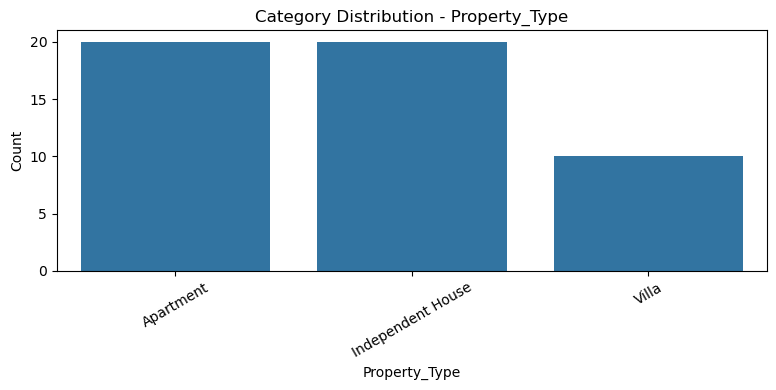

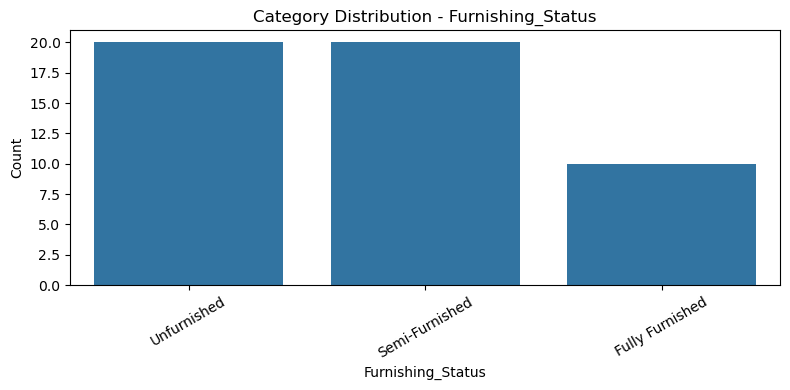

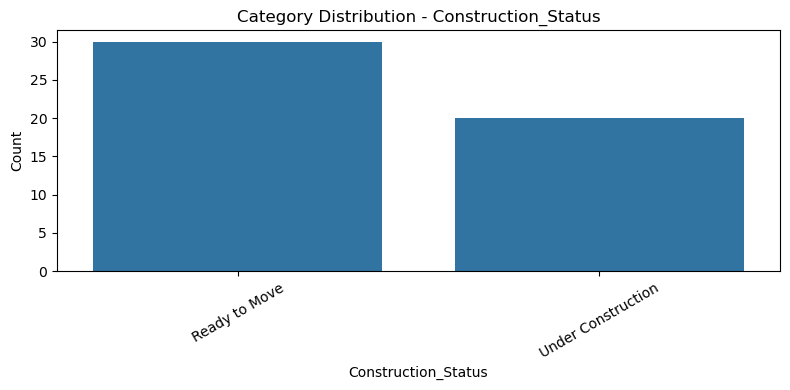

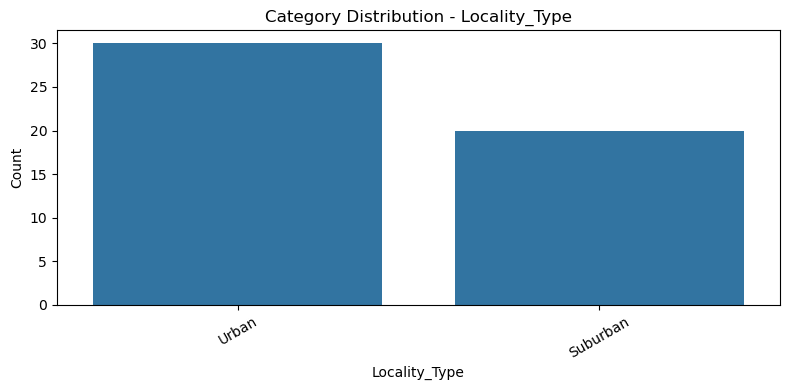

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in categorical_cols:
    
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Category Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### 7. Identify Rare Categories


In [30]:

#Here, we consider categories appearing in less than 5% of the data as rare.

rare_threshold = 0.05


for col in categorical_cols:
    
    proportions = df[col].value_counts(normalize=True)
    
    rare_categories = proportions[
        proportions < rare_threshold
    ]
    
    print(f"\n===== {col} =====")
    
    if len(rare_categories) == 0:
        print("No rare categories found.")
    else:
        print("Rare Categories:")
        print(rare_categories)


===== Property_Type =====
No rare categories found.

===== Furnishing_Status =====
No rare categories found.

===== Construction_Status =====
No rare categories found.

===== Locality_Type =====
No rare categories found.


### 8. Low Cardinality and High Cardinality

In [31]:
cardinality = pd.DataFrame({
    "Column": categorical_cols,
    "Unique_Categories": [
        df[col].nunique() for col in categorical_cols
    ]
})

cardinality["Cardinality"] = np.where(
    cardinality["Unique_Categories"] <= 10,
    "Low Cardinality",
    "High Cardinality"
)

display(cardinality)

,Column,Unique_Categories,Cardinality
0,Property_Type,3,Low Cardinality
1,Furnishing_Status,3,Low Cardinality
2,Construction_Status,2,Low Cardinality
3,Locality_Type,2,Low Cardinality
